## SickleShield - Component 2 EDA
### Status: Completed data exploration and preprocessing
### Next: Cell 7 - Class weights, then data loaders, then ResNet training

In [ ]:
import os
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("Working directory:", os.getcwd())

In [2]:
sickle_pos = '../data/sickle/Positive'
sickle_neg = '../data/sickle/Negative/Clear'

def count_images(folder):
    count = 0
    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                count += 1
    return count

print(f"Positive (sickle) images: {count_images(sickle_pos)}")
print(f"Negative (normal) images: {count_images(sickle_neg)}")

Positive (sickle) images: 844
Negative (normal) images: 147


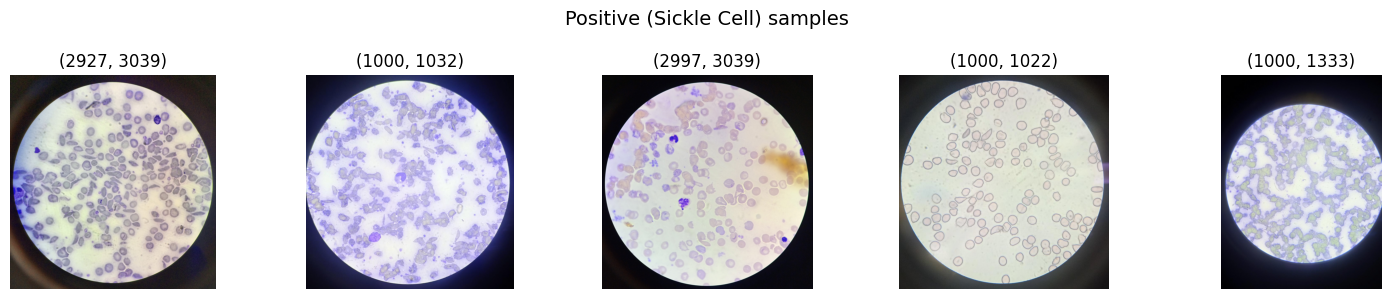

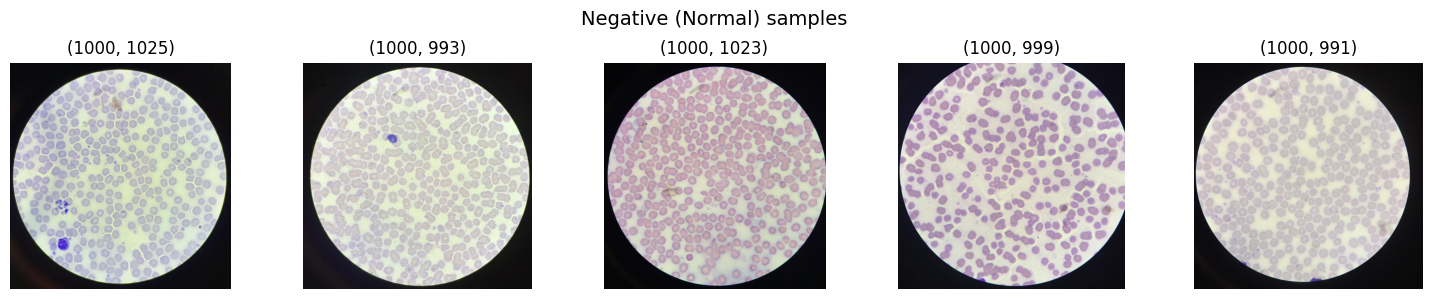

In [3]:
def show_sample_images(folder, label, n=5):
    images = []
    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                images.append(os.path.join(root, file))
    
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    fig.suptitle(f'{label} samples', fontsize=14)
    
    for i, ax in enumerate(axes):
        img = Image.open(images[i]).convert('RGB')
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f'{img.size}')
    
    plt.tight_layout()
    plt.show()

show_sample_images(sickle_pos, 'Positive (Sickle Cell)')
show_sample_images(sickle_neg, 'Negative (Normal)')

In [4]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness = 0.2, contrast = 0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                         std = [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                         std = [0.229, 0.224, 0.225])
])

print("Transforms defined.")

Transforms defined.


In [5]:
import shutil

os.makedirs('../data/processed/sickle', exist_ok=True)
os.makedirs('../data/processed/normal', exist_ok=True)

def copy_images(src_folder, dst_folder):
    count = 0
    for root, dirs, files in os.walk(src_folder):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                src = os.path.join(root, file)
                
                new_name = f"{count:04d}_{file}"
                dst = os.path.join(dst_folder, new_name)
                shutil.copy2(src, dst)
                count += 1
    return count

sickle_count = copy_images('../data/sickle/Positive', '../data/processed/sickle')
normal_count = copy_images('../data/sickle/Negative/Clear', '../data/processed/normal')

print(f"Sickle images copied: {sickle_count}")
print(f"Normal images copied: {normal_count}")

Sickle images copied: 844
Normal images copied: 147


In [6]:
sickle_processed = count_images('../data/processed/sickle')
normal_processed = count_images('../data/processed/normal')

print(f"Processed sickle images: {sickle_processed}")
print(f"Processed normal images: {normal_processed}")
print(f"Total: {sickle_processed + normal_processed}")
print(f"Class ratio: {sickle_processed/normal_processed:.2f}:1")

Processed sickle images: 844
Processed normal images: 147
Total: 991
Class ratio: 5.74:1


In [7]:
total = sickle_processed + normal_processed
weight_normal = total / (2 * normal_processed)
weight_sickle = total / (2 * sickle_processed)

print(f"Weight for normal class: {weight_normal:.4f}")
print(f"Weight for sickle class: {weight_sickle:.4f}")

class_weights = torch.tensor([weight_normal, weight_sickle])
print(f"Class weights tensor: {class_weights}")

Weight for normal class: 3.3707
Weight for sickle class: 0.5871
Class weights tensor: tensor([3.3707, 0.5871])
